### File Structure

There are many files here which may look overwhelming. 

This notebook should contain all information you need in order to execute and use DiffLogic, though you may wish to modify and understand the remaining files.

For that, I have included below a brief description of each folder/file and how they should be used:

```.
├── config/
│   ├── MNIST_hyperparameters.csv         # Comma separated valued (CSV) excel sheet where you may set # of layers and hyperparameters for your model
│   ├── csv_to_yaml_mnist.ipynb           # Jupyter Notebook for converting the CSV into a YAML configuration file.
│   ├── mnist_config.yaml                 # Configuration file for the 180 different DiffLogic model architectures
├── data-mnist/
│   ├── MNIST/                            # MNIST dataset files (e.g., training and test sets)
├── trained_models/
│   ├── *.pth                             # Trained DiffLogic model files saved as .pth
├── DiffLogic.py                          # Class definition for the DiffLogic model
└── MnistTrainer.ipynb                    # Jupyter notebook for training the DiffLogic models on MNIST
```

### DiffLogic Installation

Brief DiffLogic installation instructions if using high performance computing. More instructions can be found [here](https://github.com/Felix-Petersen/difflogic/blob/main/INSTALLATION_SUPPORT.md)

```python
1. module load conda
2. conda create --prefix=./difflogic_env python=3.9 -y
3. conda activate difflogic_env
4. conda install pip
5. pip install ipykernel
6. python -m ipykernel install --user --name=difflogic_env --display-name="DIFFLOGIC"
7. module load cuda/11.1.0
8. pip install torch==1.9.0+cu111 torchvision==0.10.0+cu111  -f https://download.pytorch.org/whl/torch_stable.html
9. mamba install cudatoolkit=11.1 
10. pip install difflogic
11. pip install -r requirements.txt
```

**The code below uses the MNIST dataset. You may want to use other datasets with different dimensions.**

**You wil need to create a config.yaml file for your desired model sizes, for that, check the `config` folder for examples on how the config.yaml files are created.**

### Class and Function declarations

##### Dependencies

In [1]:
import pandas as pd
from sklearn.model_selection import train_test_split
import torch 
from torch import nn
from difflogic import LogicLayer, GroupSum
import numpy as np
import matplotlib.pyplot as plt
from torchviz import make_dot
import sys
# used to train the DiffLogic models with different configs taken from config.yaml
from hydra import compose, initialize
from omegaconf import OmegaConf, DictConfig
import torch
import os
from torch.utils.data import DataLoader
import random

# Fix random seeds for reproducibility
torch.manual_seed(42)             # PyTorch seed fixing
torch.cuda.manual_seed(42)        # PyTorch CUDA seed fixing (if using GPU)
np.random.seed(42)                # NumPy seed fixing
random.seed(42)                   # Python's built-in random seed fixing

# If using CUDA:
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False

##### Dataset

In [2]:
import mnist_dataset
from torch.utils.data import DataLoader, Dataset, TensorDataset
import torchvision.transforms as transforms

batch_size = 256 # this can be tuned as well

train_dataset = mnist_dataset.MNIST('./data-mnist', train=True, download=True)
test_dataset = mnist_dataset.MNIST('./data-mnist', train=False)

train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True, pin_memory=True, drop_last=True)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False, pin_memory=True, drop_last=True)

##### DiffLogic Class

In [3]:
class DiffLogic(nn.Module):
    def __init__(self, layers_config, output_size, tau=30):
        """
        Initializes the DiffLogic model with the specified layer configurations, output size, and temperature parameter.

        Args:
            layers_config (dict): Configuration for each logic layer, including dimensions, device, implementation, connections, and grad factor.
            output_size (int): The number of output groups.
            tau (int): Temperature parameter for the GroupSum operation.
        """
        super(DiffLogic, self).__init__()
        self.flatten = nn.Flatten()
        
        layers = []
        for layer_name, config in layers_config.items():
            layer = LogicLayer(
                in_dim=config['in_dim'],
                out_dim=config['out_dim'],
                device=config['device'],
                implementation=config['implementation'],
                connections=config['connections'],
                grad_factor=config['grad_factor']       
            )
            layers.append(layer)
            print(layer)
        
        self.logic_layers = nn.Sequential(*layers)
        
        self.group = GroupSum(k=output_size, tau=tau)
    
    def forward(self, x):
        """
        Forward pass of the DiffLogic model.

        Args:
            x (torch.Tensor): Input tensor.

        Returns:
            torch.Tensor: Output tensor after processing through the logic layers and grouping operation.
        """
        # Move tensor to GPU
        if torch.cuda.is_available():
            x = x.to('cuda')          
        x = self.flatten(x)
        logits = self.logic_layers(x)
        group = self.group(logits)
        return group

##### Model Class

In [4]:
class Model(nn.Module):
    def __init__(self, cfg):
        """
        Initializes the Model, loads the DiffLogic model, sets up the optimizer, loss function, and other necessary configurations.

        Args:
            cfg (dict): Configuration dictionary containing model parameters such as layer configurations, output size, tau, and learning rate.
        """
        super(Model, self).__init__()
        
        layers_config = cfg["layers_config"]
        output_size = cfg["output_size"]
        tau = cfg["tau"]
                
        self.diff_logic_model = DiffLogic(layers_config, output_size=output_size, tau=tau)
        self.optimizer = torch.optim.Adam(self.diff_logic_model.parameters(), lr=cfg["learning_rate"])
        self.log_text = ""  # Initialize the logging string
        self.data_batch = []
        self.criterion = nn.CrossEntropyLoss() # loss function for classification tasks

        self.inputs = ["data_id"]
        self.outputs = ["state_id"]
        self.dtrain = ["reward", "state_id", "state_id_label"]
        self.needs = list(np.unique(self.dtrain + self.inputs))

    def forward(self, prediction_dict):    
        """
        Forward pass to predict the model output.

        Args:
            prediction_dict (dict): Dictionary containing input data for making predictions.

        Returns:
            None: Updates the prediction_dict with the predicted output data.
        """
        input_data = prediction_dict["input_data"]
        output = self.diff_logic_model(input_data)
        self.log_text += f"State Prediction: {output}\n"
        prediction_dict["pred_output_data"] = output

    def loss(self, prediction, label):
        """
        Computes the loss between the predicted and true labels.

        Args:
            prediction (torch.Tensor): Predicted tensor output from the model.
            label (torch.Tensor): True labels tensor.

        Returns:
            torch.Tensor: The computed loss value.
        """
        return self.criterion(prediction, label)

    def step(self):
        """
        Updates the model parameters by performing a single optimization step.

        Returns:
            None
        """
        self.optimizer.step()

    def train(self, tdata, mem, batch_size):
        """
        Training method that returns the loss after receiving a batch of data.

        Args:
            tdata (any): Training data.
            mem (any): Memory buffer or additional data needed for training.
            batch_size (int): Size of the data batch for training.

        Returns:
            torch.Tensor: The loss value for the batch.
        """
        self.optimizer.zero_grad()
        loss = torch.tensor([0.0 for i in range(batch_size)])
        return loss

    def test_train(self, prediction_dict):
        """
        Training method for system development on a dummy dataset.

        Args:
            prediction_dict (dict): Dictionary containing predicted and true output data.

        Returns:
            torch.Tensor: The computed loss.
        """
        self.optimizer.zero_grad()
        loss = self.loss(prediction_dict["pred_output_data"], prediction_dict["true_output_data"]).flatten()  # Structure loss (DNN relies on down-stream prediction)  
        return loss

    def save(self, file_path, model_name='model'):
        """
        Saves the model's state dictionary to the specified file path.

        Args:
            file_path (str): Path where the model will be saved.
            model_name (str): Name of the saved model

        Returns:
            None
        """
        torch.save({
            'model_state_dict': self.diff_logic_model.state_dict(),
            'connections': [layer.indices for layer in self.diff_logic_model.logic_layers if isinstance(layer, LogicLayer)]
        }, os.path.join(file_path, f"{model_name}.pth"))
        self.log_text += f"Model saved to: {file_path}\n"

    def load(self, file_path):
        """
        Loads the model's state dictionary from the specified file path.

        Args:
            file_path (str): Path from which the model will be loaded.

        Returns:
            None
        """
        checkpoint = torch.load(file_path)
        self.diff_logic_model.load_state_dict(checkpoint['model_state_dict'])

        # Assign connections to each LogicLayer
        for idx, layer in enumerate(self.diff_logic_model.logic_layers):
            if isinstance(layer, LogicLayer):
                layer.indices = checkpoint['connections'][idx]

        self.diff_logic_model.eval()
        self.log_text += f"Model loaded from: {file_path}\n"

    def plot_loss(self, loss_history):
        """
        Plots the training loss over epochs.

        Args:
            loss_history (list): List containing the loss values for each epoch.

        Returns:
            None
        """
        plt.figure()
        plt.plot(loss_history, label='Loss')
        plt.xlabel('Epoch')
        plt.ylabel('Loss')
        plt.title('Training Loss Over Epochs')
        plt.legend()
        plt.show()
        self.log_text += "Loss plot generated\n"

    def visualize_model(self):
        """
        Generates a visualization of the model using a dummy input.

        Returns:
            None
        """
        dummy_input = torch.randn(1, cfg["input_dim"])  # Adjust this as needed based on your input dimensions
        y = self.diff_logic_model(dummy_input)
        g = make_dot(y, params=dict(self.diff_logic_model.named_parameters()))
        g.view()
        self.log_text += "Model visualization generated\n"

    def get_log(self):
        """
        Retrieves the log text and clears the log after retrieval.

        Returns:
            str: The log text.
        """
        log_copy = self.log_text
        self.log_text = ""  # Clear the log after returning
        return log_copy

    def explain(self):
        """
        Placeholder function for explaining the model's decisions.

        Returns:
            None
        """
        return None
    
    def get_accuracy(self, data_loader):
        """
        Calculates the accuracy of the model against a data loader
        
        Args:
            data_loader: a DataLoader object, e.g. train_loader or test_loader
            
        Returns:
            float: The accuracy
        """
        correct = 0
        total = 0
    
        # Ensure model is in evaluation mode
        self.diff_logic_model.eval()

        with torch.no_grad():  # Disable gradient calculation for inference
            for batch_inputs, batch_outputs in tqdm(data_loader, desc="Running Inference"):
                batch_inputs, batch_outputs = batch_inputs.to('cuda'), batch_outputs.to('cuda')

                # Forward pass to get predictions
                outputs = self.diff_logic_model(batch_inputs)

                # Get the predicted class (index of the maximum logit)
                _, predicted = torch.max(outputs.data, 1)

                # Count correct predictions
                total += batch_outputs.size(0)  # Total number of samples in the batch
                correct += (predicted == batch_outputs).sum().item()  # Count correct predictions

        accuracy = correct / total
        return accuracy

##### EarlyStopper class

In [6]:
class EarlyStopper:
    def __init__(self, patience=10, min_delta=0):
        """
        Initializes the EarlyStopper to stop training if the performance doesn't improve after a certain number of epochs.

        Args:
            patience (int): Number of epochs to wait for an improvement.
            min_delta (float): Minimum change to consider an improvement.
        """
        self.patience = patience
        self.min_delta = min_delta
        self.best_loss = None
        self.counter = 0

    def should_stop(self, current_loss):
        """
        Check if training should stop based on the current loss.

        Args:
            current_loss (float): The current loss.

        Returns:
            bool: True if training should stop, False otherwise.
        """
        if self.best_loss is None:
            self.best_loss = current_loss
            return False
        elif current_loss < self.best_loss - self.min_delta:
            self.best_loss = current_loss
            self.counter = 0
            return False
        else:
            self.counter += 1
            print("EarlyStopper Triggered: ", self.counter)
            if self.counter >= self.patience:
                return True
            return False

In [137]:
def save_model_state(model, optimizer, model_cfg, all_models_dict, file_path, model_name, epoch, batch_size):
    # Create a dictionary to save everything
    save_dict = {
        'model_state_dict': model.diff_logic_model.state_dict(),  # Save model weights
        'optimizer_state_dict': optimizer.state_dict(),  # Save optimizer state
        'model_cfg': model_cfg,  # Save model config parameters from config.yaml
        'losses': all_models_dict[model_name]['losses'],  # Save training loss history
        'num_epochs': epoch,  # Save number of epochs
        'batch_size': batch_size  # Save batch size
    }

    # Save the dictionary as a .tar file
    save_path = os.path.join(file_path, f"{model_name}.tar")
    torch.save(save_dict, save_path)
    print(f"Model and information saved to: {save_path}")

In [138]:
def load_model_state(file_path, model_name):
    # Load the saved file
    load_path = os.path.join(file_path, f"{model_name}.tar")
    checkpoint = torch.load(load_path)

    # Initialize the model using the saved config
    model_cfg = checkpoint['model_cfg']
    model = Model(model_cfg).to('cuda')

    # Load the saved model state dict
    model.diff_logic_model.load_state_dict(checkpoint['model_state_dict'])

    # If you need to resume training, load the optimizer state dict as well
    optimizer = torch.optim.Adam(model.diff_logic_model.parameters(), lr=model_cfg["learning_rate"])
    optimizer.load_state_dict(checkpoint['optimizer_state_dict'])

    # Other saved information
    losses = checkpoint['losses']
    num_epochs = checkpoint['num_epochs']
    batch_size = checkpoint['batch_size']

    print(f"Model loaded from {load_path}")
    return model, optimizer, losses, num_epochs, batch_size

##### Displays all models in config.yaml

In [139]:
def func(model_cfg: DictConfig):
    working_dir = os.getcwd()
    #print(f"The current working directory is {working_dir}")

    # Access model-specific elements of the config
    print(f"The input dimension is {model_cfg.input_dim}")
    print(f"The learning rate is {model_cfg.learning_rate}")
    print(f"The Logic Layers are:")
    for layer_name in model_cfg.layers_config.items():
        print("\t", layer_name)

if __name__ == "__main__":
    # Initialize Hydra with the config path and job name
    with initialize(version_base=None, config_path="config", job_name="test_app"):
        cfg = compose(config_name="mnist_config")
        
    # Access all models in config.yaml
    for model_name, model_cfg in cfg.models.items():
        print(f"\n\nProcessing {model_name}")
        func(model_cfg)



Processing high_accuracy_model_config
The input dimension is 784
The learning rate is 0.01
The Logic Layers are:
	 ('LogicLayer001', {'connections': 'random', 'device': 'cuda', 'grad_factor': 3, 'implementation': 'cuda', 'in_dim': 784, 'out_dim': 64000})
	 ('LogicLayer002', {'connections': 'random', 'device': 'cuda', 'grad_factor': 3, 'implementation': 'cuda', 'in_dim': 64000, 'out_dim': 64000})
	 ('LogicLayer003', {'connections': 'random', 'device': 'cuda', 'grad_factor': 3, 'implementation': 'cuda', 'in_dim': 64000, 'out_dim': 64000})
	 ('LogicLayer004', {'connections': 'random', 'device': 'cuda', 'grad_factor': 3, 'implementation': 'cuda', 'in_dim': 64000, 'out_dim': 64000})
	 ('LogicLayer005', {'connections': 'random', 'device': 'cuda', 'grad_factor': 3, 'implementation': 'cuda', 'in_dim': 64000, 'out_dim': 64000})
	 ('LogicLayer006', {'connections': 'random', 'device': 'cuda', 'grad_factor': 3, 'implementation': 'cuda', 'in_dim': 64000, 'out_dim': 64000})


Processing model_000


### Single Model

#### Training

In [7]:
from tqdm import tqdm
losses = []
model_name = 'model_107'

# Initialize Hydra with the config path and job name
with initialize(version_base=None, config_path="config", job_name="test_app"):
    # Compose the configuration by specifying the config name
    cfg = compose(config_name="mnist_config")

# Access the configuration for a specific model (e.g., model_001)
model_cfg = cfg.models[model_name]
print(model_cfg)

{'input_dim': 784, 'layers_config': {'LogicLayer001': {'connections': 'random', 'device': 'cuda', 'grad_factor': 1, 'implementation': 'cuda', 'in_dim': 784, 'out_dim': 10000}, 'LogicLayer002': {'connections': 'random', 'device': 'cuda', 'grad_factor': 1, 'implementation': 'cuda', 'in_dim': 10000, 'out_dim': 10000}, 'LogicLayer003': {'connections': 'random', 'device': 'cuda', 'grad_factor': 1, 'implementation': 'cuda', 'in_dim': 10000, 'out_dim': 10000}, 'LogicLayer004': {'connections': 'random', 'device': 'cuda', 'grad_factor': 1, 'implementation': 'cuda', 'in_dim': 10000, 'out_dim': 10000}, 'LogicLayer005': {'connections': 'random', 'device': 'cuda', 'grad_factor': 1, 'implementation': 'cuda', 'in_dim': 10000, 'out_dim': 10000}}, 'learning_rate': 0.01, 'output_size': 10, 'tau': 30}


In [8]:
model = Model(model_cfg).to('cuda')

# Initialize EarlyStopper with a patience of 10 epochs
early_stopper = EarlyStopper(patience=10)

num_epochs = 10
losses = []

for epoch in range(num_epochs):
    loop = tqdm(train_loader, leave=True, desc=f'Epoch {epoch+1}/{num_epochs}')
    epoch_loss = 0  # Track loss for the entire epoch
    
    for batch_inputs, batch_outputs in loop:
        # Move to GPU if available
        batch_inputs, batch_outputs = batch_inputs.to('cuda').double(), batch_outputs.to('cuda').long()
        
        # Create prediction dictionary
        prediction_dict = {
            "input_data": batch_inputs, 
            "true_output_data": batch_outputs
        }
                
        # Forward pass
        model.forward(prediction_dict)
        
        # Compute the loss
        loss = model.test_train(prediction_dict)
        
        # Zero gradients, backpropagate, and update the model parameters
        model.optimizer.zero_grad()
        loss.backward()
        model.step()

        # Accumulate the batch loss
        epoch_loss += loss.item()
    
    # Calculate the average loss for the epoch
    epoch_loss /= len(train_loader)
    losses.append(epoch_loss)
    print(f'Epoch {epoch+1} Loss: {epoch_loss}')

    # Check if we should stop early
    if early_stopper.should_stop(epoch_loss):
        print(f"Early stopping triggered at epoch {epoch+1}. Training stopped.")
        break

# Save the model after training completes
FILE_PATH = 'trained_models'
FILE_NAME = f'{model_name}_weights'
model.save(FILE_PATH, FILE_NAME)

LogicLayer(784, 10000, train)
LogicLayer(10000, 10000, train)
LogicLayer(10000, 10000, train)
LogicLayer(10000, 10000, train)
LogicLayer(10000, 10000, train)


Epoch 1/10: 100%|██████████| 234/234 [00:08<00:00, 27.33it/s]


Epoch 1 Loss: 1.785918021327937


Epoch 2/10: 100%|██████████| 234/234 [00:05<00:00, 40.21it/s]


Epoch 2 Loss: 0.4734893563273139


...

Epoch 8 Loss: 0.2209385986143259


Epoch 9/10: 100%|██████████| 234/234 [00:05<00:00, 40.08it/s]


Epoch 9 Loss: 0.21281337638547368


Epoch 10/10: 100%|██████████| 234/234 [00:05<00:00, 39.91it/s]


Epoch 10 Loss: 0.20604865863536317


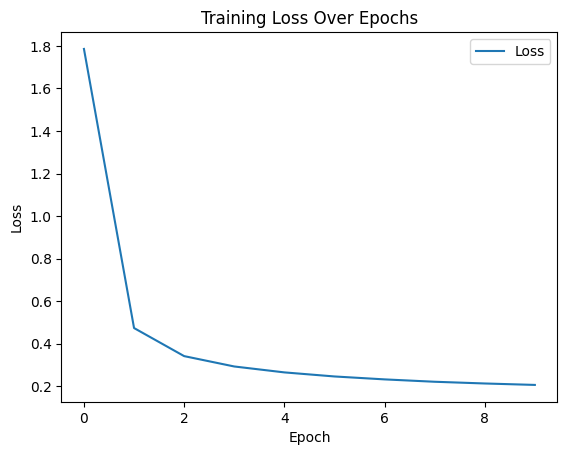

In [9]:
model.plot_loss(losses)

#### Inference

In [10]:
model_name = 'model_107'
model_name_config = model_name # from mnist_config.yaml
model_name_weights = f'{model_name}_weights' # trained weights in model_name.pth
trained_models_dir = 'trained_models'
PATH = f'{trained_models_dir}/{model_name_weights}.pth'

# ensure you have a "mnist_config.yaml" file within a "config" folder
with initialize(version_base=None, config_path="config", job_name="test_app"):
    cfg = compose(config_name="mnist_config")

# access the configuration for a specific model (e.g., model_000)
model_cfg = cfg['models'][model_name_config]

# instantiate the model and load its weights
model = Model(model_cfg).to('cuda')
model.load(PATH)
# print(model)

model.get_accuracy(test_loader)

LogicLayer(784, 10000, train)
LogicLayer(10000, 10000, train)
LogicLayer(10000, 10000, train)
LogicLayer(10000, 10000, train)
LogicLayer(10000, 10000, train)


Running Inference: 100%|██████████| 39/39 [00:01<00:00, 29.71it/s]


0.9482171474358975

### All Models

#### Training

In [ ]:
all_models_dict = {}
num_epochs = 10
file_path = 'trained_models'

# Initialize Hydra with the config path and job name
with initialize(version_base=None, config_path="config", job_name="test_app"):
    cfg = compose(config_name="mnist_config")

for model_name, model_cfg in cfg.models.items():
    print(f'training model {model_name}')

    # Initialize the dictionary entry for the model with an empty list for losses and other features
    all_models_dict[model_name] = {
        'losses': [],
        # Add other features here, e.g., 'accuracy': [], 'other_feature': []
    }

    try:
        # Initialize the model
        model = Model(model_cfg).to('cuda')
        optimizer = model.optimizer  
        
        # Initialize EarlyStopper for each model
        early_stopper = EarlyStopper(patience=10)  # Adjust patience as needed

        for epoch in range(num_epochs):
            loop = tqdm(train_loader, leave=True, desc=f'Epoch {epoch+1}/{num_epochs}')
            epoch_loss = 0  # Track the loss for the epoch
            
            for batch_inputs, batch_outputs in loop:
                # Move to GPU if available
                batch_inputs, batch_outputs = batch_inputs.to('cuda').double(), batch_outputs.to('cuda').long()

                # Create prediction dictionary
                prediction_dict = {
                    "input_data": batch_inputs, 
                    "true_output_data": batch_outputs
                }

                # Forward pass
                model.forward(prediction_dict)

                # Compute the loss
                loss = model.test_train(prediction_dict)

                # Zero gradients, backpropagate, and update the model parameters
                model.optimizer.zero_grad()
                loss.backward()
                model.step()
                
                # Accumulate loss for the epoch
                epoch_loss += loss.item()

            # Calculate average loss for the epoch
            epoch_loss /= len(train_loader)
            all_models_dict[model_name]['losses'].append(epoch_loss)
            print(f'Epoch {epoch+1} Loss: {epoch_loss}')

            # Check for early stopping
            if early_stopper.should_stop(epoch_loss):
                print(f"Early stopping triggered for {model_name} at epoch {epoch+1}.")
                break

        # Save the trained model
        model.save(file_path, model_name)
        
        # Save the trained model metadata
        save_model_state(model, optimizer, model_cfg, all_models_dict, metadata_file_path, model_name, num_epochs, batch_size)        
    
    except Exception as e:
        print(f"ERROR TRAINING {model_name.upper()}: {str(e)}")

print("All models processed.")

training model model_20x20
LogicLayer(400, 1000, train)
LogicLayer(1000, 1000, train)
LogicLayer(1000, 1000, train)
LogicLayer(1000, 1000, train)
LogicLayer(1000, 1000, train)


Epoch 1/10:   0%|          | 0/234 [00:00<?, ?it/s]


ERROR TRAINING MODEL_20X20: (torch.Size([784, 256]), 400)
training model model_x
LogicLayer(784, 1000, train)
LogicLayer(1000, 1000, train)
LogicLayer(1000, 1000, train)
LogicLayer(1000, 1000, train)
LogicLayer(1000, 1000, train)


Epoch 1/10: 100%|██████████| 234/234 [00:04<00:00, 52.59it/s]


Epoch 1 Loss: 2.1941848975304


...

Epoch 3/10: 100%|██████████| 234/234 [00:07<00:00, 30.80it/s]


Epoch 3 Loss: 2.3007044828591963


Epoch 4/10: 100%|██████████| 234/234 [00:06<00:00, 35.04it/s]


Epoch 4 Loss: 2.3004375298094053


Epoch 5/10:  78%|███████▊  | 183/234 [00:05<00:01, 35.10it/s]

#### Inference

In [56]:
trained_models_dir = 'trained_models'

# Get a list of all model files in the directory
model_files = sorted([f for f in os.listdir(trained_models_dir) if f.endswith('.pth')])

with initialize(version_base=None, config_path="config", job_name="test_app"):
    cfg = compose(config_name="mnist_config")

# Loop through all model files and calculate their accuracies
for model_file in model_files:
    model_name = model_file.removesuffix('.pth')
    model_cfg = cfg['models'][model_name]
    
    # instantiate the model and load its weights
    model = Model(model_cfg).to('cuda')
    
    model_path = os.path.join(trained_models_dir, model_file)
    print(f"Evaluating {model_file}...")

    # Load the model
    model.load(model_path)

    # Calculate accuracy
    accuracy = calculate_accuracy(model, test_loader)
    
    print(f"Accuracy of {model_file}: {accuracy * 100:.2f}%\n")

LogicLayer(784, 64000, train)
LogicLayer(64000, 64000, train)
LogicLayer(64000, 64000, train)
LogicLayer(64000, 64000, train)
LogicLayer(64000, 64000, train)
LogicLayer(64000, 64000, train)
Evaluating model_000.pth...


Running Inference: 100%|██████████| 39/39 [00:00<00:00, 46.47it/s]


Accuracy of model_000.pth: 9.75%

LogicLayer(784, 100000, train)
Evaluating model_001.pth...


Running Inference: 100%|██████████| 39/39 [00:00<00:00, 67.17it/s]


Accuracy of model_001.pth: 9.90%

LogicLayer(784, 20000, train)
LogicLayer(20000, 20000, train)
LogicLayer(20000, 20000, train)
LogicLayer(20000, 20000, train)
LogicLayer(20000, 20000, train)
Evaluating model_002.pth...


...

Running Inference: 100%|██████████| 39/39 [00:00<00:00, 65.78it/s]


Accuracy of model_063.pth: 10.32%

LogicLayer(784, 2000, train)
LogicLayer(2000, 2000, train)
LogicLayer(2000, 2000, train)
LogicLayer(2000, 2000, train)
LogicLayer(2000, 2000, train)
LogicLayer(2000, 2000, train)
LogicLayer(2000, 2000, train)
LogicLayer(2000, 2000, train)
LogicLayer(2000, 2000, train)
LogicLayer(2000, 2000, train)
LogicLayer(2000, 2000, train)
LogicLayer(2000, 2000, train)
LogicLayer(2000, 2000, train)
LogicLayer(2000, 2000, train)
LogicLayer(2000, 2000, train)
LogicLayer(2000, 2000, train)
LogicLayer(2000, 2000, train)
LogicLayer(2000, 2000, train)
LogicLayer(2000, 2000, train)
LogicLayer(2000, 2000, train)
LogicLayer(2000, 2000, train)
LogicLayer(2000, 2000, train)
LogicLayer(2000, 2000, train)
LogicLayer(2000, 2000, train)
LogicLayer(2000, 2000, train)
LogicLayer(2000, 2000, train)
LogicLayer(2000, 2000, train)
LogicLayer(2000, 2000, train)
LogicLayer(2000, 2000, train)
LogicLayer(2000, 2000, train)
LogicLayer(2000, 2000, train)
LogicLayer(2000, 2000, train)
LogicL

Running Inference: 100%|██████████| 39/39 [00:00<00:00, 58.60it/s]


Accuracy of model_064.pth: 11.35%

LogicLayer(784, 1000, train)
LogicLayer(1000, 1000, train)
LogicLayer(1000, 1000, train)
LogicLayer(1000, 1000, train)
LogicLayer(1000, 1000, train)
LogicLayer(1000, 1000, train)
LogicLayer(1000, 1000, train)
LogicLayer(1000, 1000, train)
LogicLayer(1000, 1000, train)
LogicLayer(1000, 1000, train)
LogicLayer(1000, 1000, train)
LogicLayer(1000, 1000, train)
LogicLayer(1000, 1000, train)
LogicLayer(1000, 1000, train)
LogicLayer(1000, 1000, train)
LogicLayer(1000, 1000, train)
LogicLayer(1000, 1000, train)
LogicLayer(1000, 1000, train)
LogicLayer(1000, 1000, train)
LogicLayer(1000, 1000, train)
LogicLayer(1000, 1000, train)
LogicLayer(1000, 1000, train)
LogicLayer(1000, 1000, train)
LogicLayer(1000, 1000, train)
LogicLayer(1000, 1000, train)
LogicLayer(1000, 1000, train)
LogicLayer(1000, 1000, train)
LogicLayer(1000, 1000, train)
LogicLayer(1000, 1000, train)
LogicLayer(1000, 1000, train)
LogicLayer(1000, 1000, train)
LogicLayer(1000, 1000, train)
LogicL

KeyboardInterrupt: 

In [35]:
calculate_accuracy(model, test_loader)

Running Inference: 100%|██████████| 39/39 [00:01<00:00, 23.80it/s]

Accuracy of the model on the test dataset: 9.75%


#### Saving Metadata

In [17]:
total_num_neurons = sum(map(lambda x: x.num_neurons, logic_layers[1:-1]))
    print(f'total_num_neurons={total_num_neurons}')
    total_num_weights = sum(map(lambda x: x.num_weights, logic_layers[1:-1]))
    print(f'total_num_weights={total_num_weights}')
    if args.experiment_id is not None:
        results.store_results({
            'total_num_neurons': total_num_neurons,
            'total_num_weights': total_num_weights,
        })

IndentationError: unexpected indent (3607706656.py, line 2)

### Unused Code

In [ ]:
model_name = 'high_accuracy_model'
model_name_config = 'high_accuracy_model_config' # from mnist_config.yaml
model_name_weights = 'high_accuracy_model_weights' # trained weights in model_name.pth
trained_models_dir = 'trained_models' # directory where all trained model weights are saved
PATH = f'{trained_models_dir}/{model_name_weights}.pth'

# ensure you have a "mnist_config.yaml" file within a "config" folder
with initialize(version_base=None, config_path="config", job_name="test_app"):
    cfg = compose(config_name="mnist_config")

# access the configuration for a specific model (e.g., model_000)
model_cfg = cfg['models'][model_name_config]
model_cfg

loaded_model = Model(model_cfg).to('cuda')

if False:
    print("Weights after initializing but before loading:")
    for name, param in loaded_model.named_parameters():
        if param.requires_grad:
            print(f"{name}: {param.data[0]}")  # Print the first element of each layer's weights for inspection
            
accuracy = calculate_accuracy2(loaded_model, test_loader)
print(f"Accuracy of {model_name}: {accuracy * 100:.2f}%\n")

# instantiate the model and load its weights
loaded_model.load(PATH)
loaded_model.to('cuda')  # Ensure the model is on the GPU after loading weights

if False:
    print("Weights after loading:")
    for name, param in model.named_parameters():
        if param.requires_grad:
            print(f"{name}: {param.data[0]}")  # Print the first element of each layer's weights for inspection

accuracy = calculate_accuracy2(loaded_model, test_loader)
print(f"Accuracy of {model_name}: {accuracy * 100:.2f}%\n")

print("Weights before loading:")
for name, param in model.named_parameters():
    if param.requires_grad:
        print(f"{name}: {param.data[0]}")  # Print the first element of each layer's weights for inspection

loaded_model.diff_logic_model.eval()
def discretize_logic_gates(model):
    with torch.no_grad():  # Disable gradient tracking
        for layer in model.diff_logic_model.logic_layers:
            if hasattr(layer, "weights"):
                # Print the original weights shape for debugging
                print(f"Original weights shape: {layer.weights.shape}")

                # Get the indices of the maximum logic gate weights (discretization)
                hard_weights = torch.argmax(layer.weights, dim=-1)  # Shape: [64000]

                # Convert to one-hot encoding
                hard_weights_one_hot = torch.zeros_like(layer.weights)
                hard_weights_one_hot.scatter_(1, hard_weights.unsqueeze(-1), 1)

                # Replace the soft weights with the hard (discretized) one-hot encoded weights
                layer.weights.detach_().copy_(hard_weights_one_hot)
    return model
loaded_model = discretize_logic_gates(loaded_model)

# comparing the two models

model_state_dict = model.state_dict()
loaded_model_state_dict = loaded_model.state_dict()

# Check if all keys (parameters/buffers) match between the models
for key in model_state_dict.keys():
    if key not in loaded_model_state_dict:
        print(f"Key {key} is missing in loaded model.")
        continue
    
    # Compare the actual values of the parameters
    if not torch.allclose(model_state_dict[key], loaded_model_state_dict[key]):
        print(f"Mismatch found in key: {key}")
    else:
        print(f"Key {key} matches.")

# Check if there are any keys in loaded_model that are not in model
for key in loaded_model_state_dict.keys():
    if key not in model_state_dict:
        print(f"Extra key {key} found in loaded model.")
        
model_keys = set(model_state_dict.keys())
loaded_model_keys = set(loaded_model_state_dict.keys())

if model_keys != loaded_model_keys:
    print("Model architectures differ in keys:")
    print(f"Model keys: {model_keys - loaded_model_keys}")
    print(f"Loaded model keys: {loaded_model_keys - model_keys}")
else:
    print("Model architectures match.")

In [ ]:
# Change all 'connections': 'random' to 'connections': 'unique'
if False:
    for layer in model_cfg['layers_config'].values():
        if layer['connections'] == 'random':
            layer['connections'] = 'unique'